<a href="https://colab.research.google.com/github/SOUJU07/Indian-Startup-Funding-/blob/main/Data_cleaning_and_Analysis_of_Indian_Startup_Funding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-startup-funding/startup_funding.csv


In [ ]:
df=pd.read_csv('/kaggle/input/indian-startup-funding/startup_funding.csv')

In [ ]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [ ]:
# dropped remarks columns

df.drop(columns=['Remarks'],inplace=True)

In [ ]:
# make Sr No as index

df.set_index('Sr No',inplace=True)

In [ ]:
df

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
...,...,...,...,...,...,...,...,...
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000"
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000"
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000"


In [ ]:
#rename columns

df.rename(columns={
    'Date dd/mm/yyyy':'Date',
    'Startup Name':'Startup',
    'Industry Vertical':'Vertical',
    'SubVertical':'Sub Vertical',
    'City  Location':'City',
    'Investors Name':'Investors',
    'InvestmentnType':'Round',
    'Amount in USD':'Amount'
},inplace=True)

In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
...,...,...,...,...,...,...,...,...
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000"
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000"
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000"


In [ ]:
# convert amount to int/float

df['Amount']

Sr No
1       20,00,00,000
2          80,48,394
3        1,83,58,860
4          30,00,000
5          18,00,000
            ...     
3040       45,00,000
3041        8,25,000
3042       15,00,000
3043             NaN
3044        1,40,000
Name: Amount, Length: 3044, dtype: object

In [ ]:
df['Amount']=df['Amount'].str.replace(',','')

In [ ]:
df['Amount']=pd.to_numeric(df['Amount'],errors='coerce').fillna(0).astype(int)

In [ ]:
df['Amount']

Sr No
1       200000000
2         8048394
3        18358860
4         3000000
5         1800000
          ...    
3040      4500000
3041       825000
3042      1500000
3043            0
3044       140000
Name: Amount, Length: 3044, dtype: int64

In [ ]:
# convert to crore

def to_cr(amount):
    inr=(amount*90)/10000000
    return inr


df['Amount']=round(df['Amount'].apply(to_cr))

In [ ]:
df['Amount'].sum()

np.float64(342466.0)

In [ ]:
# convert date column to datetime
df['Date']=pd.to_datetime(df['Date'],format='mixed',
    dayfirst=True,
    errors='coerce')

In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount
Sr No,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0
...,...,...,...,...,...,...,...,...
3040,2015-01-29,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,40.0
3041,2015-01-29,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,7.0
3042,2015-01-30,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,14.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3044 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          3040 non-null   datetime64[ns]
 1   Startup       3044 non-null   object        
 2   Vertical      2873 non-null   object        
 3   Sub Vertical  2108 non-null   object        
 4   City          2864 non-null   object        
 5   Investors     3020 non-null   object        
 6   Round         3040 non-null   object        
 7   Amount        3044 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 214.0+ KB


In [ ]:
df = df.dropna(subset=['Date','Startup','Vertical','City','Investors','Round','Amount'])

In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount
Sr No,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0
...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2833 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2833 non-null   datetime64[ns]
 1   Startup       2833 non-null   object        
 2   Vertical      2833 non-null   object        
 3   Sub Vertical  2079 non-null   object        
 4   City          2833 non-null   object        
 5   Investors     2833 non-null   object        
 6   Round         2833 non-null   object        
 7   Amount        2833 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 199.2+ KB


In [ ]:
df.to_csv('Startup_India_Cleaned.csv',index=False)

# Investor POV


In [ ]:
# Name

df['Investors'] #there are lots of investor for single investment , so we have to break
                # it to single single


investor_names = sorted(set(df['Investors'].str.split(',').sum())) # for filtering investors name

type(investor_names)

list

In [ ]:
# Recent 5 investment by an investor

recent_investment = df[df['Investors'].str.contains(' IDG Ventures')][['Date','Startup','Vertical','City','Round','Amount']].sort_values('Date',ascending=False).head()

recent_investment

,Date,Startup,Vertical,City,Round,Amount
Sr No,,,,,,
102,2019-04-13,Tripoto,Social Media,New Delhi,Series B,32.0
259,2018-05-02,Bizongo,Consumer Internet,Mumbai,Private Equity,198.0
310,2018-04-26,POPxo,Technology,Delhi,Private Equity,50.0
505,2017-11-21,Heckyl,Technology,Mumbai,Private Equity,24.0
528,2017-10-05,Little Black Book,Consumer Internet,New Delhi,Private Equity,9.0


In [ ]:
# biggest investment

biggest_investments = df[df['Investors'].str.contains(' IDG Ventures')].groupby('Startup')['Amount'].sum().sort_values(ascending=False)

biggest_investments

Startup
Lenskart                 540.0
CureFit                  225.0
Bizongo                  198.0
Curefit                  135.0
Xpressbees               112.0
FirstCry.com              90.0
POPxo                     78.0
\\xc2\\xa0CloudCherry     54.0
Sigtuple                  52.0
Aasaanjobs                45.0
RentMojo                  45.0
PlaySimple                36.0
Tripoto                   32.0
Active.ai                 27.0
Heckyl                    24.0
Cloudcherry Analytics      9.0
Little Black Book          9.0
Name: Amount, dtype: float64

<Axes: ylabel='Amount'>

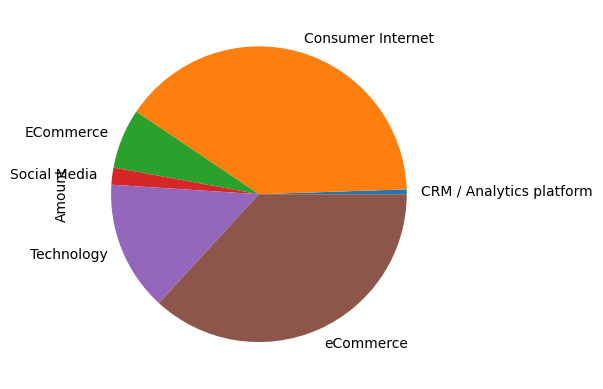

In [ ]:
# vertical/sector wise investment , show pie chart

vertical_wise = df[df['Investors'].str.contains(' IDG Ventures')].groupby('Vertical')['Amount'].sum()

vertical_wise.plot(kind='pie')

<Axes: ylabel='Amount'>

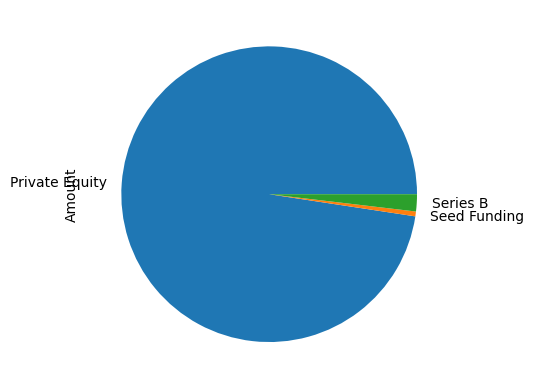

In [ ]:
# show investment in pie chart for round wise

round_wise = df[df['Investors'].str.contains(' IDG Ventures')].groupby(['Round'])['Amount'].sum()
round_wise.plot(kind='pie')

<Axes: ylabel='Amount'>

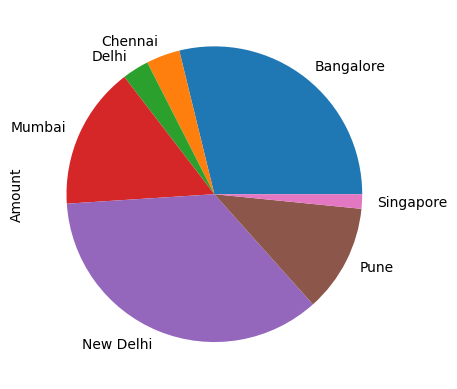

In [ ]:
# city wise investment done in pie chart

city_wise = df[df['Investors'].str.contains(' IDG Ventures')].groupby('City')['Amount'].sum()

city_wise.plot(kind='pie')

In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount
Sr No,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0
...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0


In [ ]:
df['year']=df['Date'].dt.year

/tmp/ipykernel_55/3002932815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year']=df['Date'].dt.year


In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020
...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015


<Axes: xlabel='year'>

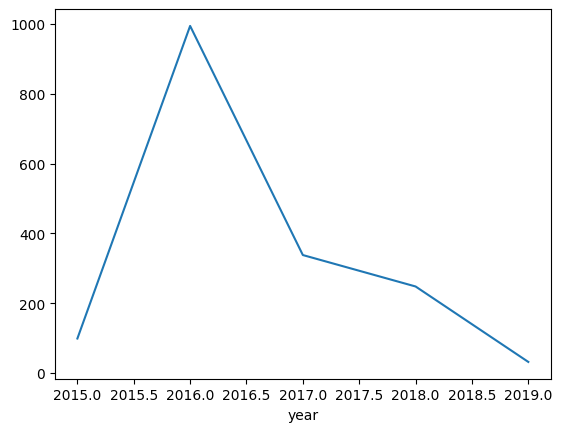

In [ ]:
# YoY investment graph

yoy_investment = df[df['Investors'].str.contains(' IDG Ventures')].groupby('year')['Amount'].sum()

yoy_investment.plot()

In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020
...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015


# Company POV


In [ ]:
# Name
startup_names = df['Startup'].to_list()

In [ ]:
startup_names[0:5]

['BYJU’S', 'Shuttl', 'Mamaearth', 'https://www.wealthbucket.in/', 'Fashor']

In [ ]:
# Name, investors, sub vertical, vertical and city

df[['Startup','Investors','Vertical','Sub Vertical','City']]

,Startup,Investors,Vertical,Sub Vertical,City
Sr No,,,,,
1,BYJU’S,Tiger Global Management,E-Tech,E-learning,Bengaluru
2,Shuttl,Susquehanna Growth Equity,Transportation,App based shuttle service,Gurgaon
3,Mamaearth,Sequoia Capital India,E-commerce,Retailer of baby and toddler products,Bengaluru
4,https://www.wealthbucket.in/,Vinod Khatumal,FinTech,Online Investment,New Delhi
5,Fashor,Sprout Venture Partners,Fashion and Apparel,Embroiled Clothes For Women,Mumbai
...,...,...,...,...,...
2869,Tracxn,SAIF Partners,Startup Analytics platform,NaN,Bangalore
2870,Dazo,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Mobile Food Ordering app,NaN,Bangalore
2871,Tradelab,Rainmatter,Financial Markets Software,NaN,Bangalore


<Axes: ylabel='Amount'>

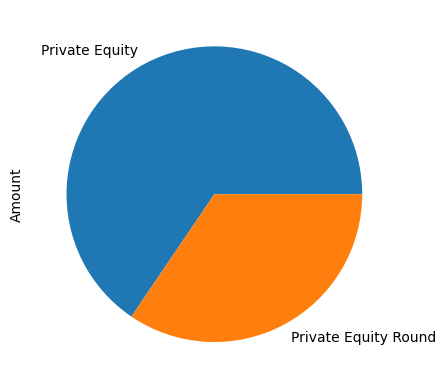

In [ ]:
# stage wise /round wise amount gathered by company

startup_stage_wise = df[df['Startup'].str.contains('Zomato')].groupby('Round')['Amount'].sum()

startup_stage_wise.plot(kind='pie')

<Axes: xlabel='Investors'>

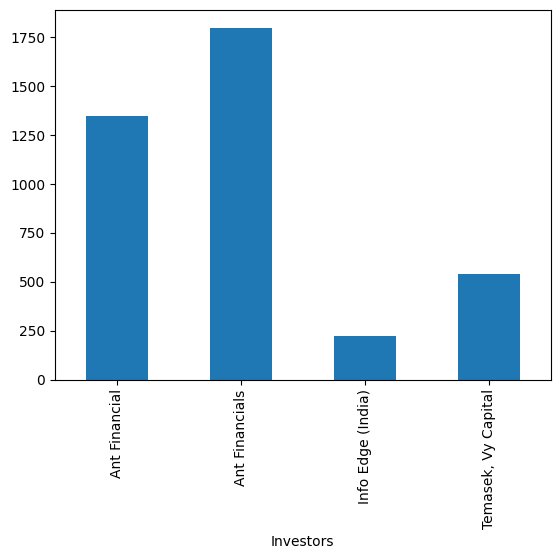

In [ ]:
# investors invested in particular company

startup_investors = df[df['Startup'].str.contains('Zomato')].groupby('Investors')['Amount'].sum()

startup_investors.plot(kind='bar')

In [ ]:
df.head()

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020


In [ ]:
# MoM chart
df['Month']=df['Date'].dt.month

/tmp/ipykernel_55/2429138297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month']=df['Date'].dt.month


In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year,Month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020,1
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015,4
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015,4
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015,4


In [ ]:
df.groupby(['year','Month'])['Startup'].count().reset_index()

,year,Month,Startup
0,2015,4,62
1,2015,5,57
2,2015,6,84
3,2015,7,95
4,2015,8,98
5,2015,9,87
6,2015,10,93
7,2015,11,90
8,2015,12,88
9,2016,1,104


<Axes: xlabel='year,Month'>

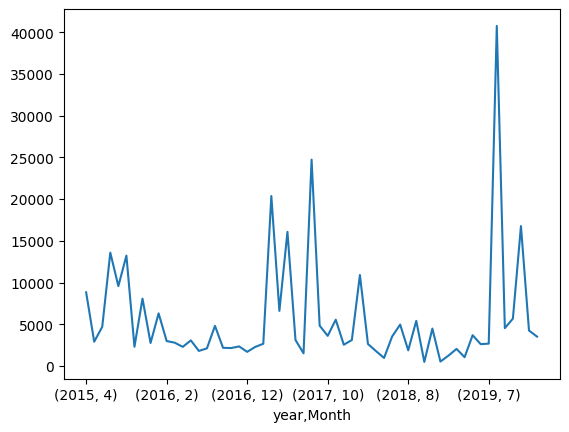

In [ ]:
mom_chart = df.groupby(['year','Month'])['Amount'].sum()

mom_chart.plot()

In [ ]:
# total investment amount

total_amount=df['Amount'].sum()
total_amount

np.float64(323481.0)

In [ ]:
# highest investment amount

highest_investment = df.groupby('Startup')['Amount'].sum().sort_values(ascending=False).head(1)

In [ ]:
highest_investment.values[0]

np.float64(36537.0)

In [ ]:
# average funding

df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year,Month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020,1
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015,4
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015,4
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015,4


In [ ]:
average_funding = df.groupby('Startup')['Amount'].sum().mean()

In [ ]:
# total funded startup

total_startup = df['Startup'].nunique()

In [ ]:
total_startup

2307

In [ ]:
df.head()

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year,Month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020,1


<Axes: ylabel='Vertical'>

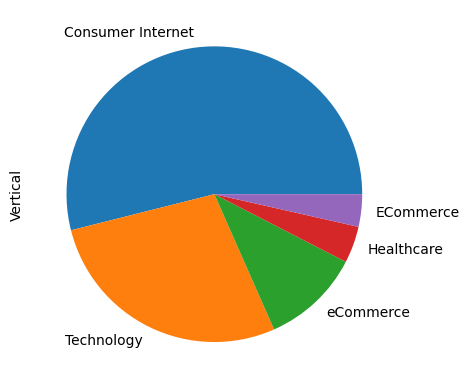

In [ ]:
# top sectors count

top_5_sectors = df.groupby('Vertical')['Vertical'].count().sort_values(ascending=False).head()

top_5_sectors.plot(kind='pie')

<Axes: xlabel='Vertical'>

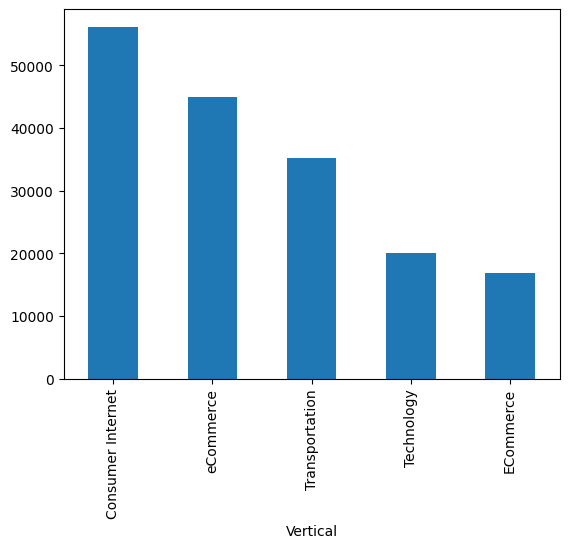

In [ ]:
# top sectors amount

top_5_sectors_amount = df.groupby('Vertical')['Amount'].sum().sort_values(ascending=False).head()

top_5_sectors_amount.plot(kind='bar')

In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year,Month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020,1
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015,4
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015,4
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015,4


In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year,Month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020,1
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015,4
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015,4
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015,4


In [ ]:
df

,Date,Startup,Vertical,Sub Vertical,City,Investors,Round,Amount,year,Month
Sr No,,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1800.0,2020,1
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,72.0,2020,1
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,165.0,2020,1
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,27.0,2020,1
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,16.0,2020,1
...,...,...,...,...,...,...,...,...,...,...
2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,32.0,2015,4
2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.0,2015,4
2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,4.0,2015,4
